In [2]:
import os
os.path.curdir
os.chdir("../")

In [ ]:
import os
import pandas as pd
import logging
from tqdm import tqdm

# ----- 로깅 설정 -----
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)

BASE_DIR = "./try11"   # make_commands_ver13.py에서 outdir로 만든 루트 경로
OUTPUT_FILE = "try11/R2_summary.csv"

results = []

# trial 폴더 탐색
for root, dirs, files in tqdm(os.walk(BASE_DIR), desc="Searching trial folders"):
    for d in dirs:
        if d.startswith("trial_"):
            trial_dir = os.path.join(root, d)
            # metrics 파일 이름 패턴 확인
            metrics_file = [f for f in os.listdir(trial_dir) if f.startswith("metrics_holdout_trial") and f.endswith(".csv")]
            if not metrics_file:
                continue
            metrics_path = os.path.join(trial_dir, metrics_file[0])

            try:
                df = pd.read_csv(metrics_path)
                if "R2" not in df.columns:
                    logging.warning(f"No R2 column in {metrics_path}")
                    continue
                r2_values = df["R2"].values
                for r in r2_values:
                    results.append({
                        "folder": root,     # 상위 조합 폴더
                        "trial": d,
                        "MAE": r
                    })
            except Exception as e:
                logging.error(f"Error reading {metrics_path}: {e}")

# DataFrame으로 정리
df_all = pd.DataFrame(results)

# 조합별 평균, 표준편차 계산
summary = df_all.groupby("folder")["MAE"].agg(["mean", "std", "count"]).reset_index()

# 저장
summary.to_csv(OUTPUT_FILE, index=False)
logging.info(f"Summary saved to {OUTPUT_FILE}")


Searching trial folders: 0it [00:00, ?it/s]

Searching trial folders: 2593it [00:03, 715.86it/s]
2025-09-14 02:46:57,274 [INFO] Summary saved to try11/R2_summary.csv


In [4]:
df_all

,folder,trial,R2
0,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_001,0.924029
1,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_002,0.922001
2,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_003,0.918509
3,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_004,0.920178
4,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_005,0.919239
...,...,...,...
2155,./try11\O2_293_0.01_to_5__struct__random_struc...,trial_001,0.433076
2156,./try11\O2_293_0.01_to_5__struct__random_struc...,trial_002,0.397360
2157,./try11\O2_293_0.01_to_5__struct__random_struc...,trial_003,0.482473
2158,./try11\O2_293_0.01_to_5__struct__random_struc...,trial_004,0.382528


In [6]:
import pandas as pd

# summary CSV 불러오기
df = pd.read_csv("try11/R2_summary.csv")
# df = pd.read_csv("try09_all/R2_summary.csv")

def parse_folder(path):
    # 경로 끝 부분만 추출
    last = path.replace("\\", "/").split("/")[-1]  
    print(last)
    # 구조: Ar_273_0.01_to_1__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05
    parts = last.split("__")
    gas_temp = parts[0]   # Ar_273_0.01_to_1
    sampling = parts[2]   # qt_then_rd
    model = parts[3]      # cat_TRAIN_RATIO0.05_QTFRAC_0.05
    
    gas = gas_temp.split("_")[0]   # Ar
    temp = gas_temp.split("_")[1]  # 273
    lowpressure = gas_temp.split("_")[2] 
    highpressure = gas_temp.split("_")[4] 
    input = parts[1]
    print(input)
    # model 부분 다시 분리
    model_split = model.split("_")
    # print(sampling)
    model_name = model_split[0]   # cat
    train_ratio = model_split[2].replace("QTFRAC","")  # 0.05
    qt_frac = model_split[-1]  # 0.05
    
    return pd.Series([gas, temp, sampling, model_name, train_ratio, qt_frac,lowpressure ,highpressure,input])

# 새로운 열 추가
df[["GAS", "TEMP", "SAMPLING", "MODEL", "TRAIN_RATIO", "QT_FRAC", "LOW", "HIGH","input"]] = df["folder"].apply(parse_folder)

# 정리된 CSV 저장
# df.to_csv("try09_all/R2_summary_parsed.csv", index=False)
df.to_csv("try11/R2_summary_parsed.csv", index=False)
print(df.head())


Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.15_QTFRAC_0.15
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.1_QTFRAC_0.1
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.25_QTFRAC_0.25
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.2_QTFRAC_0.2
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.35_QTFRAC_0.35
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.3_QTFRAC_0.3
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.45_QTFRAC_0.45
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.4_QTFRAC_0.4
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.55_QTFRAC_0.55
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.5_QTFRAC_0.5
struct+input
Ar_293_0.01_to_15__s

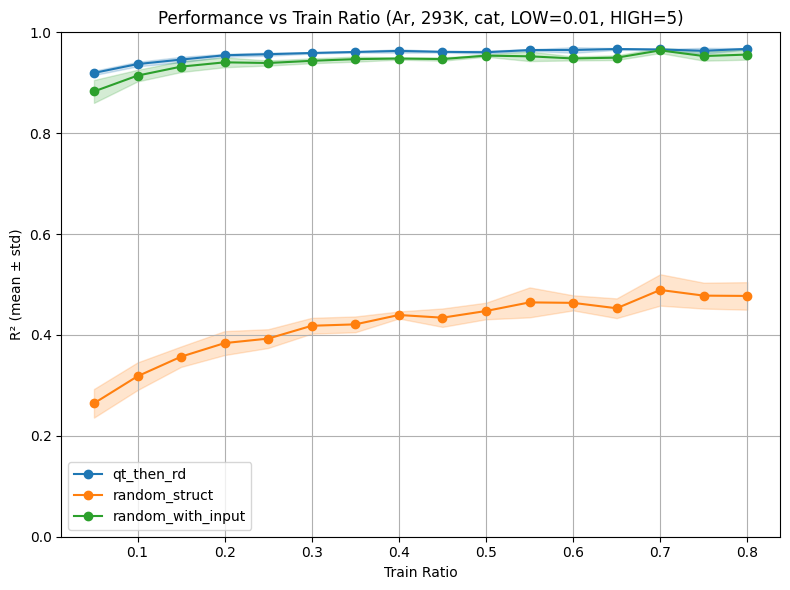

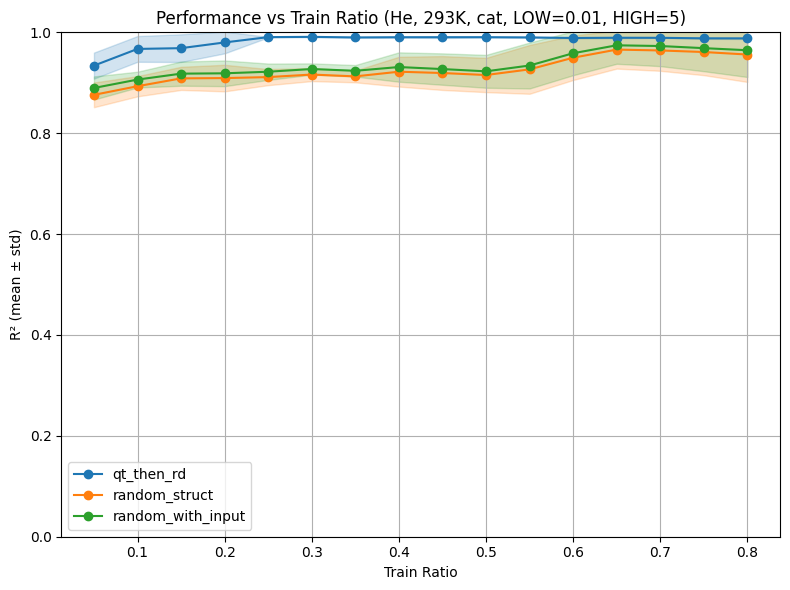

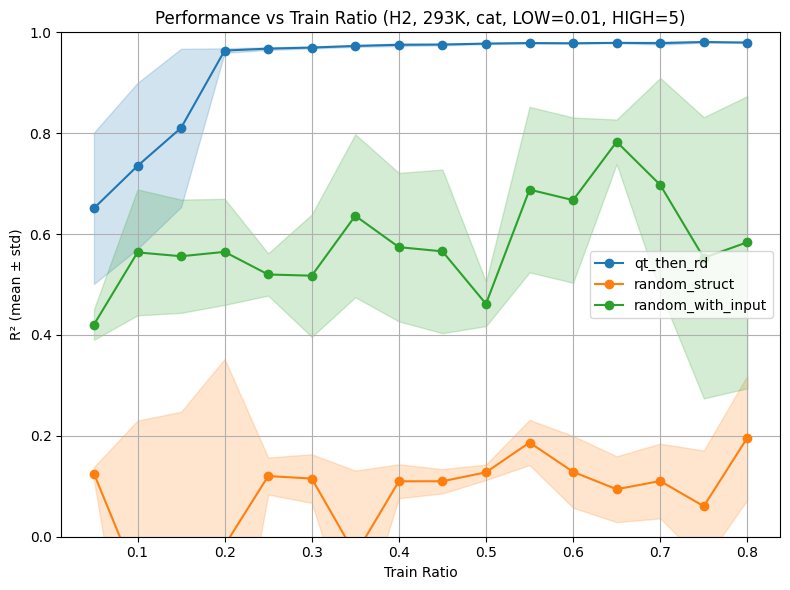

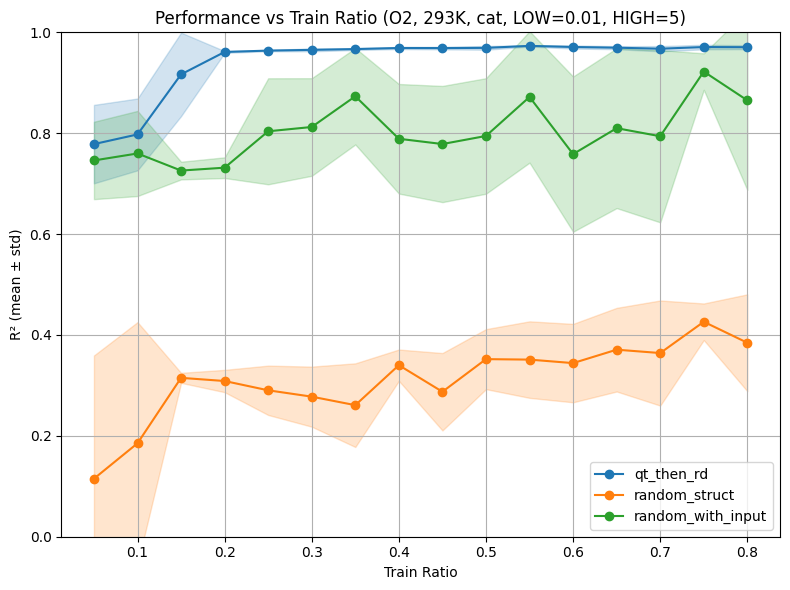

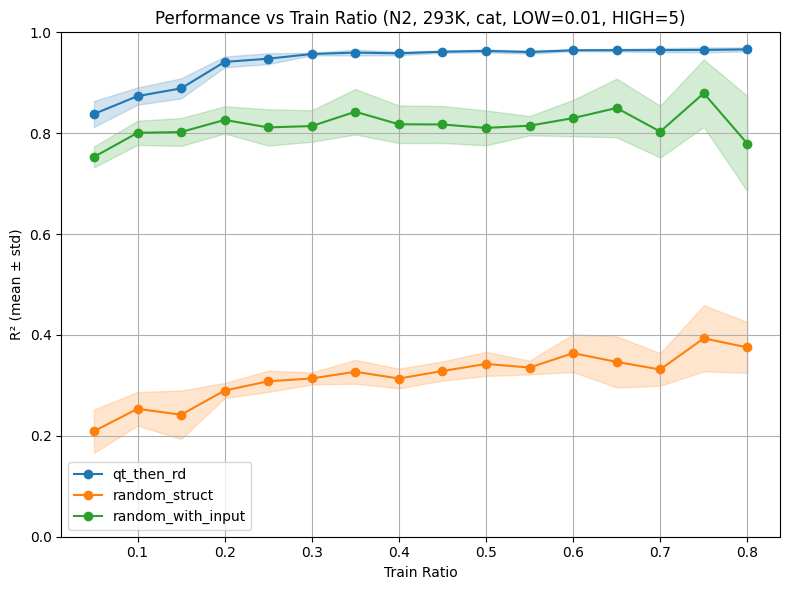

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
DF = pd.read_csv("./try11/R2_summary_parsed.csv")
# LOW=0.01, HIGH=5만 필터링
DF15 = DF[(DF["LOW"] == 0.01) & (DF["HIGH"] == 5)]

# 다중 열 기준 정렬
DF15_sorted = DF15.sort_values(
    by=["GAS", "TEMP", "MODEL", "LOW", "HIGH", "QT_FRAC", "SAMPLING"],
    ascending=[True, True, True, True, True, True, True]
).reset_index(drop=True)

# 분석 대상 GAS 리스트
gases = ["Ar", "He", "H2", "O2", "N2"]

colors = {
    "qt_then_rd": "tab:blue",
    "random_struct": "tab:orange",
    "random_with_input": "tab:green"
}

# 각 GAS별 플롯
for gas in gases:
    subset_gas = DF15_sorted[DF15_sorted["GAS"] == gas].copy()

    # "RATIO0.05" → 0.05 변환
    subset_gas["TRAIN_RATIO"] = subset_gas["TRAIN_RATIO"].str.replace("RATIO", "").astype(float)

    plt.figure(figsize=(8,6))
    for sampling in ["qt_then_rd", "random_struct", "random_with_input"]:
        subset = subset_gas[subset_gas["SAMPLING"] == sampling]

        x = subset["TRAIN_RATIO"]
        y = subset["mean"]
        yerr = subset["std"]

        plt.plot(x, y, marker="o", linestyle="-", label=sampling, color=colors[sampling])
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.2, color=colors[sampling])

    plt.ylim(0, 1)
    plt.xlabel("Train Ratio")
    plt.ylabel("R² (mean ± std)")
    plt.title(f"Performance vs Train Ratio ({gas}, 293K, cat, LOW=0.01, HIGH=5)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/He_293K/He_293K_He_293_0.01_to_He_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 36.39058709688256
Skewness (scipy, unbiased): 36.39058709688256
Skewness (pandas): 36.187923096341166
Skewness (scipy, unbiased): 36.187923096341166


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/Ar_293K/Ar_293K_Ar_293_0.01_to_Ar_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 45.407536294736964
Skewness (scipy, unbiased): 45.40753629473696
Skewness (pandas): 1.88034806755763
Skewness (scipy, unbiased): 1.88034806755763


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/N2_293K/N2_293K_N2_293_0.01_to_N2_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 43.74960913545923
Skewness (scipy, unbiased): 43.74960913545923
Skewness (pandas): 4.024766697128202
Skewness (scipy, unbiased): 4.024766697128202


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/O2_293K/O2_293K_O2_293_0.01_to_O2_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 60.4286128073127
Skewness (scipy, unbiased): 60.4286128073127
Skewness (pandas): 8.93984424625177
Skewness (scipy, unbiased): 8.939844246251774


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/H2_293K/H2_293K_H2_293_0.01_to_H2_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 64.3180275944539
Skewness (scipy, unbiased): 64.31802759445391
Skewness (pandas): 24.39940144754575
Skewness (scipy, unbiased): 24.399401447545753


In [8]:
import os
import pandas as pd
import logging
from tqdm import tqdm

# ----- 로깅 설정 -----
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)

BASE_DIR = "./try11"   # make_commands_ver13.py에서 outdir로 만든 루트 경로
OUTPUT_FILE = "try11/MAE_summary.csv"

results = []

# trial 폴더 탐색
for root, dirs, files in tqdm(os.walk(BASE_DIR), desc="Searching trial folders"):
    for d in dirs:
        if d.startswith("trial_"):
            trial_dir = os.path.join(root, d)
            # metrics 파일 이름 패턴 확인
            metrics_file = [f for f in os.listdir(trial_dir) if f.startswith("metrics_holdout_trial") and f.endswith(".csv")]
            if not metrics_file:
                continue
            metrics_path = os.path.join(trial_dir, metrics_file[0])

            try:
                df = pd.read_csv(metrics_path)
                if "MAE" not in df.columns:
                    logging.warning(f"No MAE column in {metrics_path}")
                    continue
                r2_values = df["MAE"].values
                for r in r2_values:
                    results.append({
                        "folder": root,     # 상위 조합 폴더
                        "trial": d,
                        "MAE": r
                    })
            except Exception as e:
                logging.error(f"Error reading {metrics_path}: {e}")

# DataFrame으로 정리
df_all = pd.DataFrame(results)

# 조합별 평균, 표준편차 계산
summary = df_all.groupby("folder")["MAE"].agg(["mean", "std", "count"]).reset_index()

# 저장
summary.to_csv(OUTPUT_FILE, index=False)
logging.info(f"Summary saved to {OUTPUT_FILE}")


Searching trial folders: 2593it [00:03, 773.59it/s]
2025-09-14 02:50:16,990 [INFO] Summary saved to try11/MAE_summary.csv


In [ ]:
df_all

,folder,trial,R2
0,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_001,0.924029
1,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_002,0.922001
2,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_003,0.918509
3,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_004,0.920178
4,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,trial_005,0.919239
...,...,...,...
2155,./try11\O2_293_0.01_to_5__struct__random_struc...,trial_001,0.433076
2156,./try11\O2_293_0.01_to_5__struct__random_struc...,trial_002,0.397360
2157,./try11\O2_293_0.01_to_5__struct__random_struc...,trial_003,0.482473
2158,./try11\O2_293_0.01_to_5__struct__random_struc...,trial_004,0.382528


In [10]:
import pandas as pd

# summary CSV 불러오기
df = pd.read_csv("try11/MAE_summary.csv")
# df = pd.read_csv("try09_all/R2_summary.csv")

def parse_folder(path):
    # 경로 끝 부분만 추출
    last = path.replace("\\", "/").split("/")[-1]  
    print(last)
    # 구조: Ar_273_0.01_to_1__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05
    parts = last.split("__")
    gas_temp = parts[0]   # Ar_273_0.01_to_1
    sampling = parts[2]   # qt_then_rd
    model = parts[3]      # cat_TRAIN_RATIO0.05_QTFRAC_0.05
    
    gas = gas_temp.split("_")[0]   # Ar
    temp = gas_temp.split("_")[1]  # 273
    lowpressure = gas_temp.split("_")[2] 
    highpressure = gas_temp.split("_")[4] 
    input = parts[1]
    print(input)
    # model 부분 다시 분리
    model_split = model.split("_")
    # print(sampling)
    model_name = model_split[0]   # cat
    train_ratio = model_split[2].replace("QTFRAC","")  # 0.05
    qt_frac = model_split[-1]  # 0.05
    
    return pd.Series([gas, temp, sampling, model_name, train_ratio, qt_frac,lowpressure ,highpressure,input])

# 새로운 열 추가
df[["GAS", "TEMP", "SAMPLING", "MODEL", "TRAIN_RATIO", "QT_FRAC", "LOW", "HIGH","input"]] = df["folder"].apply(parse_folder)

# 정리된 CSV 저장
# df.to_csv("try09_all/R2_summary_parsed.csv", index=False)
df.to_csv("try11/MAE_summary_parsed.csv", index=False)
print(df.head())
df

Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.15_QTFRAC_0.15
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.1_QTFRAC_0.1
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.25_QTFRAC_0.25
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.2_QTFRAC_0.2
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.35_QTFRAC_0.35
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.3_QTFRAC_0.3
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.45_QTFRAC_0.45
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.4_QTFRAC_0.4
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.55_QTFRAC_0.55
struct+input
Ar_293_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.5_QTFRAC_0.5
struct+input
Ar_293_0.01_to_15__s

,folder,mean,std,count,GAS,TEMP,SAMPLING,MODEL,TRAIN_RATIO,QT_FRAC,LOW,HIGH,input
0,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,0.254583,0.004099,5,Ar,293,qt_then_rd,cat,RATIO0.05,0.05,0.01,15,struct+input
1,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,0.211778,0.002682,5,Ar,293,qt_then_rd,cat,RATIO0.15,0.15,0.01,15,struct+input
2,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,0.227933,0.004322,5,Ar,293,qt_then_rd,cat,RATIO0.1,0.1,0.01,15,struct+input
3,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,0.197788,0.003120,5,Ar,293,qt_then_rd,cat,RATIO0.25,0.25,0.01,15,struct+input
4,./try11\Ar_293_0.01_to_15__struct+input__qt_th...,0.200926,0.001463,5,Ar,293,qt_then_rd,cat,RATIO0.2,0.2,0.01,15,struct+input
...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,./try11\O2_293_0.01_to_5__struct__random_struc...,0.317189,0.007986,5,O2,293,random_struct,cat,RATIO0.65,0.65,0.01,5,struct
428,./try11\O2_293_0.01_to_5__struct__random_struc...,0.318054,0.004302,5,O2,293,random_struct,cat,RATIO0.6,0.6,0.01,5,struct
429,./try11\O2_293_0.01_to_5__struct__random_struc...,0.313738,0.006339,5,O2,293,random_struct,cat,RATIO0.75,0.75,0.01,5,struct
430,./try11\O2_293_0.01_to_5__struct__random_struc...,0.314324,0.007758,5,O2,293,random_struct,cat,RATIO0.7,0.7,0.01,5,struct


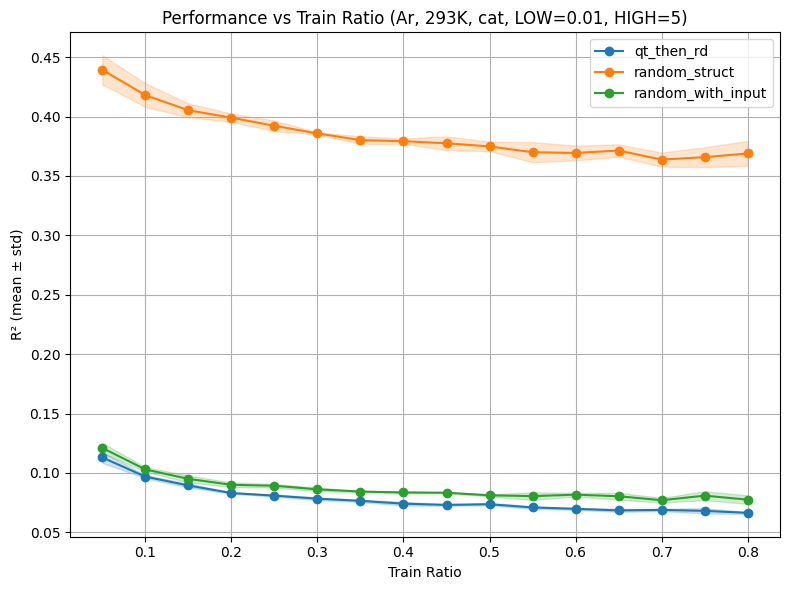

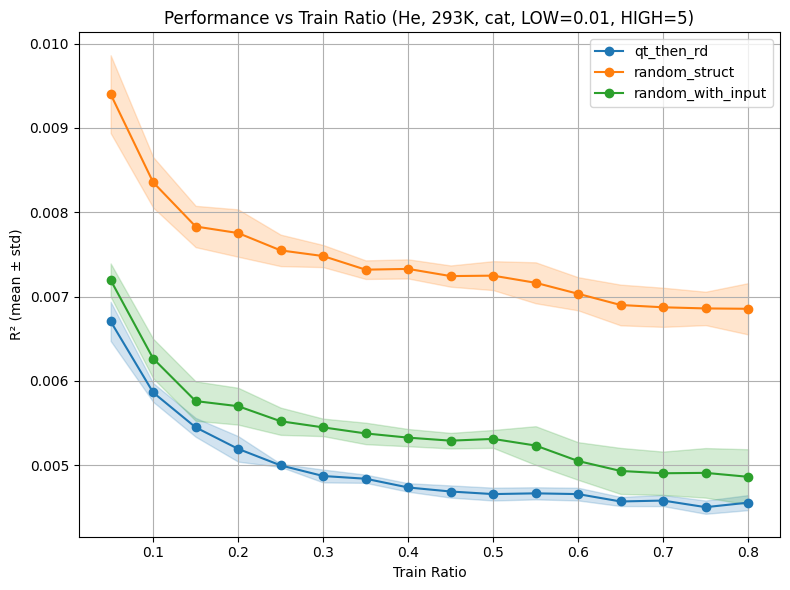

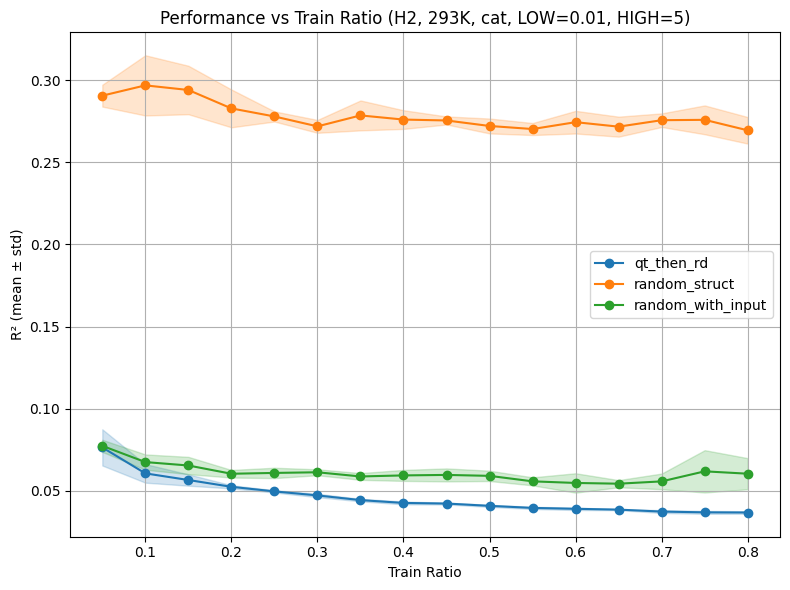

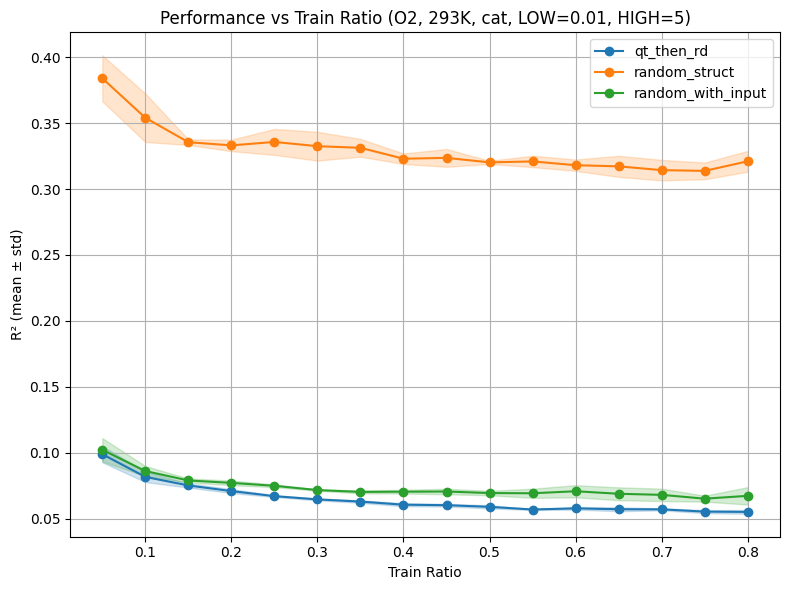

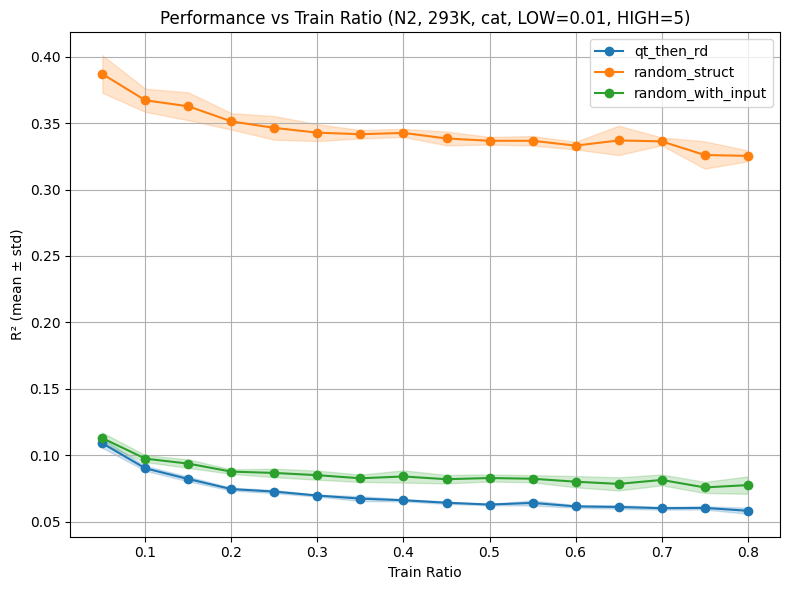

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
DF = pd.read_csv("./try11/MAE_summary_parsed.csv")
# LOW=0.01, HIGH=5만 필터링
DF15 = DF[(DF["LOW"] == 0.01) & (DF["HIGH"] == 5)]

# 다중 열 기준 정렬
DF15_sorted = DF15.sort_values(
    by=["GAS", "TEMP", "MODEL", "LOW", "HIGH", "QT_FRAC", "SAMPLING"],
    ascending=[True, True, True, True, True, True, True]
).reset_index(drop=True)

# 분석 대상 GAS 리스트
gases = ["Ar", "He", "H2", "O2", "N2"]

colors = {
    "qt_then_rd": "tab:blue",
    "random_struct": "tab:orange",
    "random_with_input": "tab:green"
}

# 각 GAS별 플롯
for gas in gases:
    subset_gas = DF15_sorted[DF15_sorted["GAS"] == gas].copy()

    # "RATIO0.05" → 0.05 변환
    subset_gas["TRAIN_RATIO"] = subset_gas["TRAIN_RATIO"].str.replace("RATIO", "").astype(float)

    plt.figure(figsize=(8,6))
    for sampling in ["qt_then_rd", "random_struct", "random_with_input"]:
        subset = subset_gas[subset_gas["SAMPLING"] == sampling]

        x = subset["TRAIN_RATIO"]
        y = subset["mean"]
        yerr = subset["std"]

        plt.plot(x, y, marker="o", linestyle="-", label=sampling, color=colors[sampling])
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.2, color=colors[sampling])

    # plt.ylim(0, 1)
    plt.xlabel("Train Ratio")
    plt.ylabel("R² (mean ± std)")
    plt.title(f"Performance vs Train Ratio ({gas}, 293K, cat, LOW=0.01, HIGH=5)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/He_293K/He_293K_He_293_0.01_to_He_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 36.39058709688256
Skewness (scipy, unbiased): 36.39058709688256
Skewness (pandas): 36.187923096341166
Skewness (scipy, unbiased): 36.187923096341166


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/Ar_293K/Ar_293K_Ar_293_0.01_to_Ar_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 45.407536294736964
Skewness (scipy, unbiased): 45.40753629473696
Skewness (pandas): 1.88034806755763
Skewness (scipy, unbiased): 1.88034806755763


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/N2_293K/N2_293K_N2_293_0.01_to_N2_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 43.74960913545923
Skewness (scipy, unbiased): 43.74960913545923
Skewness (pandas): 4.024766697128202
Skewness (scipy, unbiased): 4.024766697128202


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/O2_293K/O2_293K_O2_293_0.01_to_O2_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 60.4286128073127
Skewness (scipy, unbiased): 60.4286128073127
Skewness (pandas): 8.93984424625177
Skewness (scipy, unbiased): 8.939844246251774


In [ ]:
import pandas as pd
from scipy.stats import skew

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/H2_293K/H2_293K_H2_293_0.01_to_H2_293_5_dataset.csv")

# Input 열 왜도 계산
input_skew_pandas = df["Input"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Input"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)
# Input 열 왜도 계산
input_skew_pandas = df["Output"].skew()  # pandas 기본
input_skew_scipy  = skew(df["Output"], bias=False)  # scipy (보정된 Fisher's skewness)

print("Skewness (pandas):", input_skew_pandas)
print("Skewness (scipy, unbiased):", input_skew_scipy)

Skewness (pandas): 64.3180275944539
Skewness (scipy, unbiased): 64.31802759445391
Skewness (pandas): 24.39940144754575
Skewness (scipy, unbiased): 24.399401447545753
